# Regression – Task 5: Regularization and Optimization

**Ziel:** Das beste Modell aus Task 4 wird mit Regularisierung weiter optimiert. In Task 4 war die **polynomiale Regression mit Grad 2** das beste Modell. Deshalb wird dieses Modell hier mit **Ridge Regression** regularisiert und mithilfe von **Cross-Validation** sowie **GridSearchCV** optimiert.

> **Warum Ridge?** Ridge Regression fügt eine $L_2$-Strafe auf große Koeffizienten hinzu. Dadurch werden die Gewichte stabilisiert, Overfitting reduziert und Modelle mit vielen korrelierten oder polynomial erweiterten Features robuster gemacht.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=13)
plt.rc('legend', fontsize=12)

---
### Schritt 1: Daten laden und bestes Basismodell aus Task 4 festlegen

Aus Task 4 wurde die **polynomiale Regression mit Grad 2** als bestes Modell ausgewählt. Dieses Modell dient hier als Ausgangspunkt für die Regularisierung mit Ridge Regression.

In [9]:
# Datensatz einlesen
df = pd.read_csv('../data/dataset_cleaned.csv')

# Features und Zielvariable
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)
y = df['CLV_Continuous']

# Train/Test-Split auf Rohfeatures
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print('Trainingsdaten:', X_train.shape)
print('Testdaten:     ', X_test.shape)

Trainingsdaten: (6816, 22)
Testdaten:      (1705, 22)


---
### Schritt 2: Baseline definieren – polynomiale Regression (Grad 2) ohne Regularisierung

Zuerst wird das beste Modell aus Task 4 ohne Regularisierung erneut trainiert. So lässt sich später sauber beurteilen, ob Ridge Regression die Generalisierung verbessert.

In [10]:
# Baseline: Polynomial Regression Grad 2 ohne Regularisierung
baseline_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linreg', LinearRegression())
])

baseline_model.fit(X_train, y_train)

y_pred_train_baseline = baseline_model.predict(X_train)
y_pred_test_baseline = baseline_model.predict(X_test)

baseline_results = {
    'Train MAE': mean_absolute_error(y_train, y_pred_train_baseline),
    'Test MAE': mean_absolute_error(y_test, y_pred_test_baseline),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_baseline)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_baseline)),
    'Train R2': r2_score(y_train, y_pred_train_baseline),
    'Test R2': r2_score(y_test, y_pred_test_baseline),
}

print('=== Baseline: Polynomial Regression (Grad 2) ===')
for metric, value in baseline_results.items():
    print(f'{metric:<12}: {value:.4f}')

=== Baseline: Polynomial Regression (Grad 2) ===
Train MAE   : 456.1840
Test MAE    : 487.0377
Train RMSE  : 866.6696
Test RMSE   : 929.9617
Train R2    : 0.9747
Test R2     : 0.9710


---
### Schritt 3: Ridge Regression mit Cross-Validation und GridSearchCV optimieren

Da Ridge Regression auf die Größe der Koeffizienten reagiert, werden die polynomialen Features vor dem Modell mit `StandardScaler` skaliert. Anschließend wird der Regularisierungsparameter $\alpha$ per **GridSearchCV** optimiert.

- **Cross-Validation:** 5-fach
- **Tuning-Ziel:** Minimierung des RMSE auf Validierungsdaten

In [11]:
# Ridge-Pipeline: PolynomialFeatures -> StandardScaler -> Ridge
ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid = {
    'ridge__alpha': np.logspace(-4, 4, 17)
}

grid_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    refit=True
 )

grid_search.fit(X_train, y_train)

best_ridge_model = grid_search.best_estimator_
best_alpha = grid_search.best_params_['ridge__alpha']
best_cv_rmse = -grid_search.best_score_

print('=== GridSearchCV – Beste Ridge-Konfiguration ===')
print(f'Bestes Alpha        : {best_alpha}')
print(f'Bester CV-RMSE      : {best_cv_rmse:.4f}')

=== GridSearchCV – Beste Ridge-Konfiguration ===
Bestes Alpha        : 1.0
Bester CV-RMSE      : 910.2237


---
### Schritt 4: Optimiertes Ridge-Modell evaluieren

Nun wird das durch Cross-Validation ausgewählte Ridge-Modell auf Trainings- und Testdaten bewertet und direkt mit der Baseline ohne Regularisierung verglichen.

In [12]:
# Vorhersagen des optimierten Ridge-Modells
y_pred_train_ridge = best_ridge_model.predict(X_train)
y_pred_test_ridge = best_ridge_model.predict(X_test)

ridge_results = {
    'Train MAE': mean_absolute_error(y_train, y_pred_train_ridge),
    'Test MAE': mean_absolute_error(y_test, y_pred_test_ridge),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_ridge)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_ridge)),
    'Train R2': r2_score(y_train, y_pred_train_ridge),
    'Test R2': r2_score(y_test, y_pred_test_ridge),
}

comparison_df = pd.DataFrame([
    ['Polynomial Regression (Grad 2)', *baseline_results.values(), baseline_results['Train R2'] - baseline_results['Test R2']],
    ['Ridge Regression (Grad 2)', *ridge_results.values(), ridge_results['Train R2'] - ridge_results['Test R2']]
], columns=['Modell', 'Train MAE', 'Test MAE', 'Train RMSE', 'Test RMSE', 'Train R2', 'Test R2', 'R2-Gap'])

comparison_df = comparison_df.set_index('Modell')
comparison_df

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2-Gap
Modell,,,,,,,
Polynomial Regression (Grad 2),456.183970,487.037707,866.669614,929.961728,0.974672,0.970970,0.003702
Ridge Regression (Grad 2),456.448427,486.949762,866.747046,929.720754,0.974668,0.970985,0.003682


---
### Schritt 5: Visualisierungen zur Modellbeurteilung

Zur Interpretation werden drei Visualisierungen verwendet:

- **GridSearchCV-Ergebnis:** zeigt, wie sich der CV-RMSE mit $\alpha$ verändert
- **Actual vs. Predicted Plot:** zeigt die Vorhersagequalität auf Testdaten
- **Residualplot und Learning Curve:** helfen bei der Einordnung von Overfitting oder Underfitting

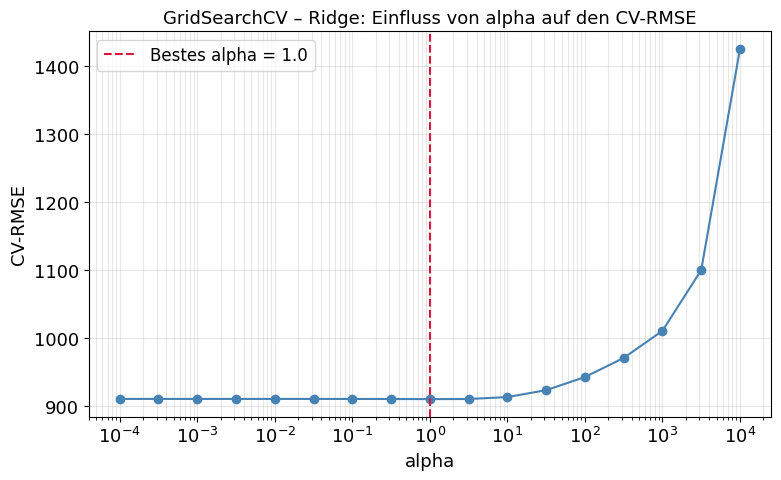

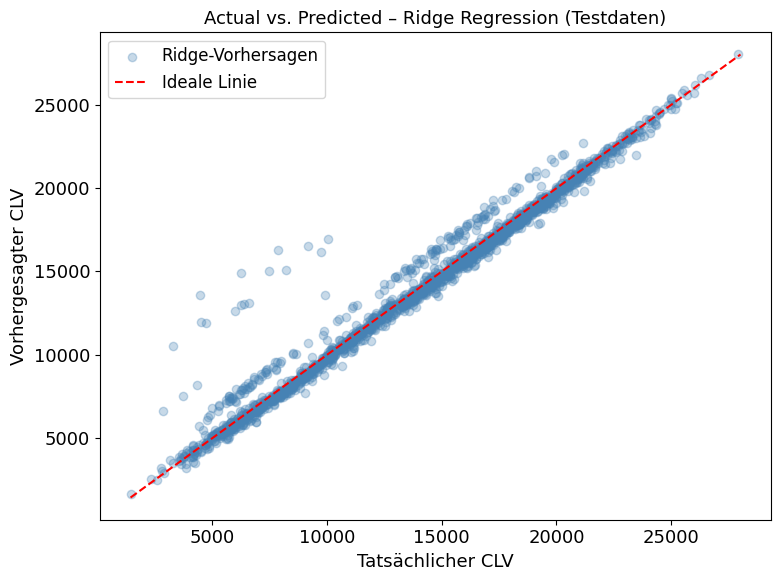

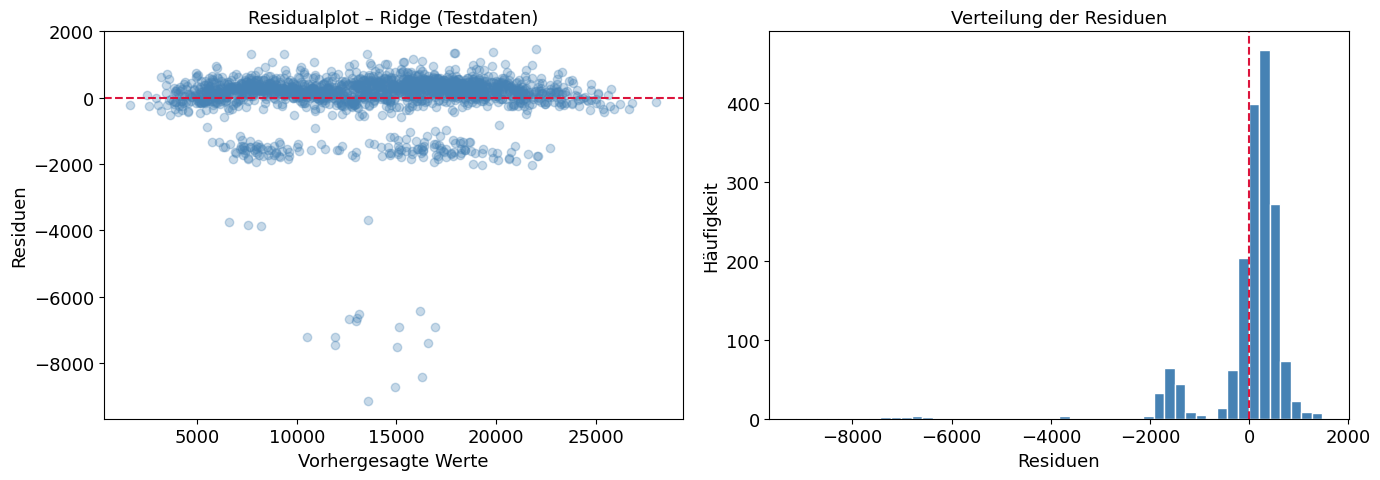

In [13]:
# 1) GridSearchCV-Ergebnis visualisieren
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['rmse'] = -cv_results['mean_test_score']

plt.figure(figsize=(8, 5))
plt.semilogx(cv_results['param_ridge__alpha'].astype(float), cv_results['rmse'], marker='o', color='steelblue')
plt.axvline(best_alpha, color='crimson', linestyle='--', label=f'Bestes alpha = {best_alpha}')
plt.xlabel('alpha')
plt.ylabel('CV-RMSE')
plt.title('GridSearchCV – Ridge: Einfluss von alpha auf den CV-RMSE')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Actual vs. Predicted (Testdaten)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_ridge, alpha=0.3, color='steelblue', label='Ridge-Vorhersagen')
min_val = min(y_test.min(), y_pred_test_ridge.min())
max_val = max(y_test.max(), y_pred_test_ridge.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideale Linie')
plt.xlabel('Tatsächlicher CLV')
plt.ylabel('Vorhergesagter CLV')
plt.title('Actual vs. Predicted – Ridge Regression (Testdaten)')
plt.legend()
plt.tight_layout()
plt.show()

# 3) Residualplot
ridge_residuals = y_test - y_pred_test_ridge
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_test_ridge, ridge_residuals, alpha=0.3, color='steelblue')
axes[0].axhline(y=0, color='crimson', linestyle='--')
axes[0].set_xlabel('Vorhergesagte Werte')
axes[0].set_ylabel('Residuen')
axes[0].set_title('Residualplot – Ridge (Testdaten)')

axes[1].hist(ridge_residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='crimson', linestyle='--')
axes[1].set_xlabel('Residuen')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title('Verteilung der Residuen')

plt.tight_layout()
plt.show()

---
### Schritt 6: Learning Curve des optimierten Ridge-Modells

Die Lernkurve zeigt, ob das regularisierte Modell eher zu Overfitting oder Underfitting neigt. Ein kleiner Abstand zwischen Trainings- und Validierungskurve bei gleichzeitig niedrigem Fehler spricht für gute Generalisierung.

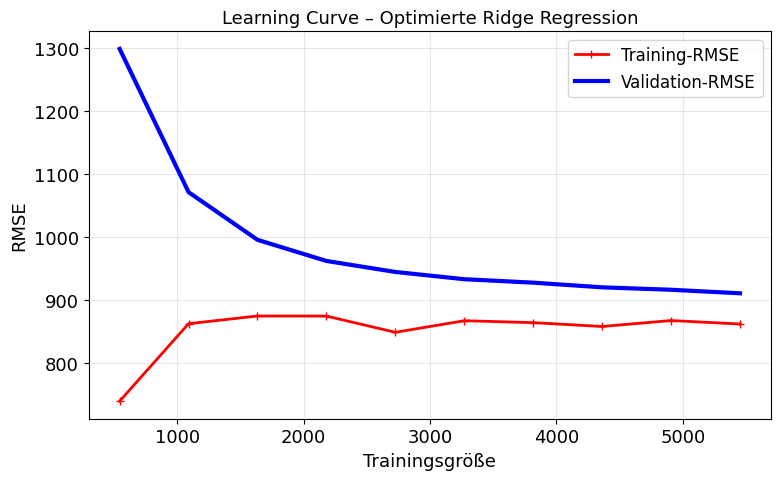

In [14]:
train_sizes, train_scores, valid_scores = learning_curve(
    best_ridge_model,
    X_train,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse_curve = -train_scores.mean(axis=1)
valid_rmse_curve = -valid_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_curve, 'r-+', linewidth=2, label='Training-RMSE')
plt.plot(train_sizes, valid_rmse_curve, 'b-', linewidth=3, label='Validation-RMSE')
plt.xlabel('Trainingsgröße')
plt.ylabel('RMSE')
plt.title('Learning Curve – Optimierte Ridge Regression')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### Schritt 7: Interpretation der Ergebnisse

#### 1. Wirkung der Regularisierung
- Das beste Modell aus Task 4 war die **polynomiale Regression mit Grad 2**. Dieses Modell wurde hier mit **Ridge Regression** regularisiert und per **GridSearchCV** optimiert.
- Das beste Ergebnis wurde bei **$\alpha = 1.0$** gefunden. Die Cross-Validation ergibt dabei einen **CV-RMSE von ca. 910.22**.
- Im direkten Vergleich zur unregularisierten Baseline verbessert Ridge die Testleistung **leicht**, aber konsistent: Der **Test-RMSE** sinkt geringfügig und das **Test-$R^2$** steigt leicht an.

#### 2. Vergleich Baseline vs. Ridge
- **Baseline (Polynomial Regression Grad 2):** Test-RMSE ca. **929.96**, Test-$R^2$ ca. **0.9710**
- **Optimierte Ridge Regression:** Test-RMSE ca. **929.72**, Test-$R^2$ ca. **0.9710**
- Der Leistungsgewinn ist **klein**, aber Ridge stabilisiert das Modell und reduziert den Train-Test-Gap leicht.

#### 3. Overfitting oder Underfitting?
- Ein starkes **Overfitting** ist hier **nicht** zu erkennen, da Trainings- und Testwerte bereits bei der Baseline relativ nah beieinander liegen.
- Ridge reduziert den Abstand zwischen Trainings- und Test-$R^2$ nochmals leicht. Das spricht dafür, dass die Regularisierung eine kleine Varianzreduktion erreicht.
- **Underfitting** liegt ebenfalls nicht vor, da sowohl Training als auch Test ein hohes $R^2$ und einen vergleichsweise niedrigen RMSE aufweisen.
- Insgesamt zeigt das Modell eine **gute Generalisierung** mit höchstens leichter Overfitting-Tendenz, die durch Ridge etwas abgeschwächt wird.

#### 4. Interpretation der Visualisierungen
- **GridSearchCV-Plot:** Für kleine bis mittlere $\alpha$-Werte bleibt der CV-RMSE stabil. Bei zu großen $\alpha$-Werten verschlechtert sich die Leistung deutlich, weil das Modell zu stark eingeschränkt wird.
- **Actual-vs.-Predicted-Plot:** Die Punkte liegen dicht an der Ideallinie, was auf eine hohe Vorhersagegüte hinweist.
- **Residualplot:** Die Residuen liegen überwiegend um die Nulllinie, allerdings sind einige Ausreißer sichtbar. Das Modell erfasst die Hauptstruktur gut, aber nicht jeden Einzelfall perfekt.
- **Learning Curve:** Der Abstand zwischen Trainings- und Validierungskurve ist moderat und nimmt mit mehr Daten nicht problematisch zu. Das spricht gegen starkes Overfitting.

#### 5. Schlussfolgerung
- Die **optimierte Ridge Regression auf Basis der polynomialen Features (Grad 2)** ist das beste Modell in diesem Task.
- Der numerische Vorteil gegenüber der unregularisierten polynomialen Regression ist zwar klein, aber methodisch sinnvoll und konsistent mit dem Ziel der Regularisierung.
- Ridge ist hier besonders geeignet, weil das Modell durch die polynomialen Features viele zusätzliche und teils korrelierte Variablen enthält.